<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1.


Sources 
1. Lecture 8
2. Lecture 9
3. https://www.youtube.com/watch?v=NcffDnVBPHA (Creating Graphs in Python)
4. https://www.youtube.com/watch?v=ewXzgCow94g (Creating Scatter Plots in Python)
5. https://htmlcolorcodes.com/ (HTML Color Codes)
6. https://stackoverflow.com/questions/8209568/how-do-i-draw-a-grid-onto-a-plot-in-python (Scatter Plot)
7. https://machinelearningplus.com/plots/python-scatter-plot/ (Scatter Plot)

In [3]:
import pandas as pd #imports pandas into python 
df = pd.read_csv(r"C:\Users\laura\OneDrive\Documents\ECO590\assignment-1-Lauramelo2005\ECO 590 - Final Project\crypto_data.csv") #imports csv into python
df.head() #prints the first 5 columns into python 

,name,current_price,market_cap,total_volume,price_change_percentage_24h,price_volatility
0,Bitcoin,71236.000000,1424373946458,3.592665e+10,0.68516,0.68516
1,Ethereum,2163.620000,261000900686,1.570007e+10,0.16145,0.16145
2,Tether,0.999613,184143769942,6.133658e+10,0.00400,0.00400
3,BNB,646.290000,88107189997,9.963930e+08,1.05591,1.05591
4,XRP,1.410000,86576589402,1.856525e+09,-0.41290,0.41290


In [5]:
top_marketcap = df.sort_values(by='market_cap', ascending=False).head(10) #creates the top 10 by market cap 

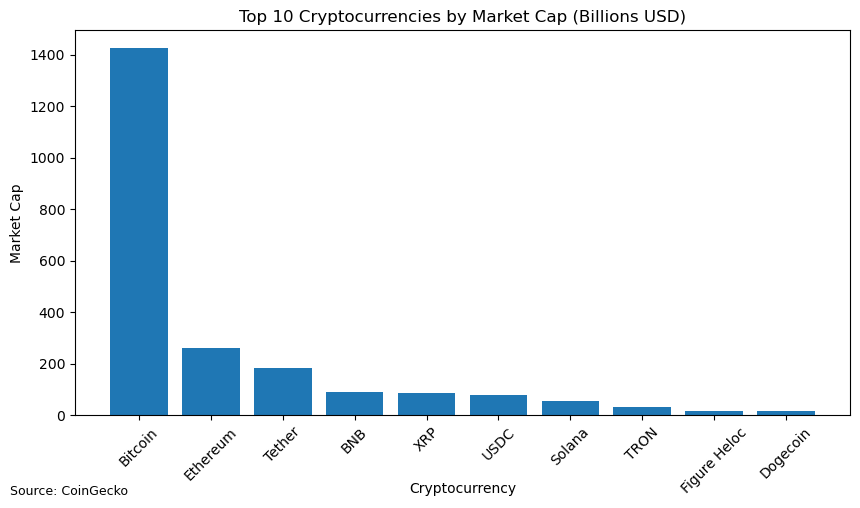

In [137]:
import matplotlib.pyplot as plt #imports the plotting library 

#creates the first bar chart - market cap 
plt.figure(figsize=(10,5)) #sets the figure size 
plt.bar(top_marketcap['name'], top_marketcap['market_cap']) #creates the bar chart
plt.title("Top 10 Cryptocurrencies by Market Cap (Billions USD)") #adds the title to the bar chart 
plt.xlabel("Cryptocurrency", labelpad=-10)
plt.ylabel("Market Cap") #y-axis label 
plt.xticks(rotation=45) #rotates the names
plt.figtext(0.06, -0.05, "Source: CoinGecko", ha="left", fontsize=9) #adds the source to the graph 

plt.savefig("market_cap_bar.png") #saves graph 
plt.show() #prints the graph 

This bar chart shows the top 10 cryptocurrencies by their market cap, with Bitcoin being the highest. This shows that a few cryptocurrencies dominate the market, especially Bitcoin. 

In [25]:
top_volume = df.sort_values(by='total_volume', ascending=False).head(10) #sorts trading volume by top 10 

In [28]:
top_volume['volume_billions'] = top_volume['total_volume'] / 1e9 #converts numbers to billions 

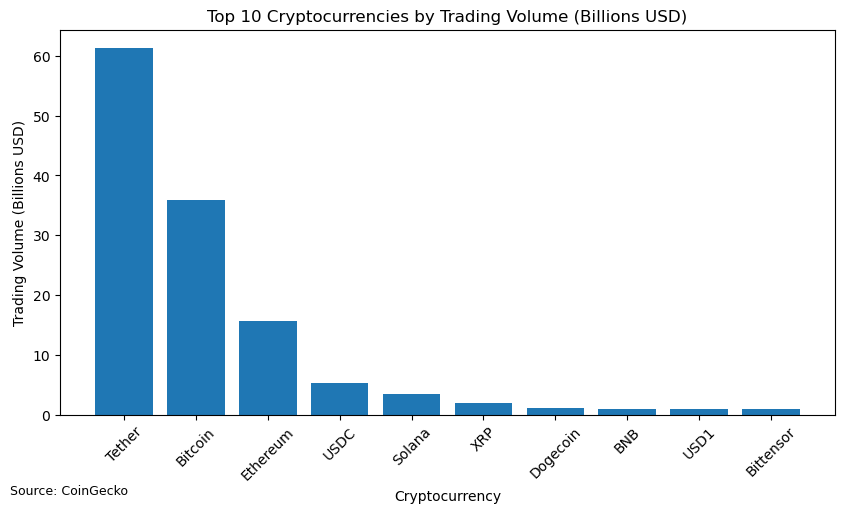

In [136]:
#creates the second bar chart - Trading Volume 
plt.figure(figsize=(10,5)) #sets the size 
plt.bar(top_volume['name'], top_volume['volume_billions']) #creates bar chart 
plt.title("Top 10 Cryptocurrencies by Trading Volume (Billions USD)") #sets title of bar chart 
plt.xlabel("Cryptocurrency", labelpad= 5) #sets the x-axis label
plt.ylabel("Trading Volume (Billions USD)") #set y-axis label
plt.xticks(rotation=45) #rotates names 
plt.figtext(0.075, -0.05, "Source: CoinGecko", ha="left", fontsize=9) #adds source to graph 

plt.savefig("trading_volume_bar.png") #saves graph 
plt.show() #prints the graph 

This bar chart shows the top 10 cryptocurrencies by their trading volume, with Tether and Bitcoin having the highest trading activity. This information shows that these coins are traded the most compared to others. 


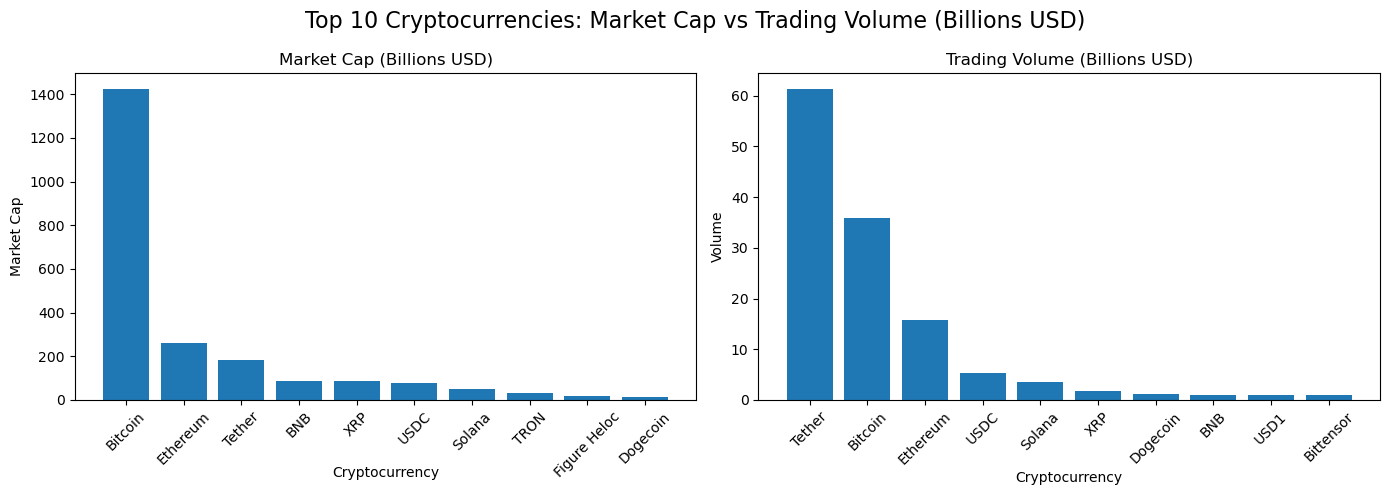

In [138]:
#shows both bar charts side by side 
fig, axes = plt.subplots(1, 2, figsize=(14,5)) #sets 1 row, 2 columns 
fig.suptitle("Top 10 Cryptocurrencies: Market Cap vs Trading Volume (Billions USD)", fontsize=16) #adds the main title 

#Graph 1 - Market Cap
axes[0].bar(top_marketcap['name'], top_marketcap['market_cap']) #creates bar chart
axes[0].set_title("Market Cap (Billions USD)") #adds the title 
axes[0].set_xlabel("Cryptocurrency", labelpad=-10) #x-axis label 
axes[0].set_ylabel("Market Cap") #y-axis label 
axes[0].tick_params(axis='x', rotation=45) #rotates the labels 

#Graph 2 - Trading Volume 
axes[1].bar(top_volume['name'], top_volume['volume_billions']) #creates bar chart
axes[1].set_title("Trading Volume (Billions USD)") #adds the title 
axes[1].set_xlabel("Cryptocurrency", labelpad= 2.5) #x-axis label 
axes[1].set_ylabel("Volume") #y-axis label 
axes[1].tick_params(axis='x', rotation=45) #rotates the labels 
plt.tight_layout() #fixes spacing 

plt.savefig("bar_side_by_side.png") #saves graph 
plt.show() #prints both graphs side by side 

These graphs side-by-side show the top 10 cryptocurrencies by market cap and trading volume. While some coins like Bitcoin have both high market cap and high trading volume, others like Tether have very high trading volume but lower market cap, which shows that size does not always match trading activity. This relates to how different cryptocurrencies behave in the market.


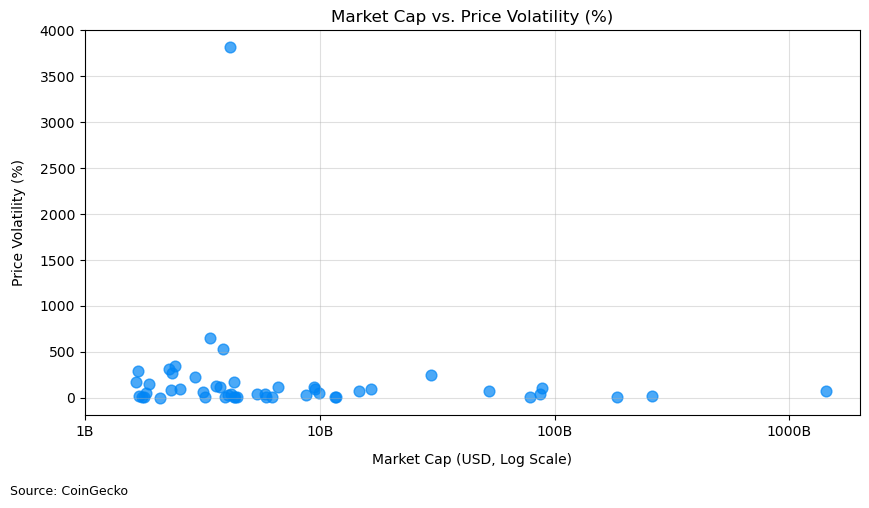

In [139]:
#creates third graph - market cap vs. price volatility 
plt.figure(figsize=(10,5)) #sets the graph size 
plt.scatter(
    df['market_cap'], 
    df['price_volatility'] * 100,
    alpha=0.7,
    s=60,
    color='#0085F5',
    label="Cryptocurrencies"
) #creates the scatter plot 

plt.xscale('log') #used log scale to show large differences in market caps 
plt.xticks([1e9, 1e10, 1e11, 1e12], ['1B', '10B', '100B', '1000B']) #customizes x-axis scale to show values in billions 
plt.minorticks_off() #removes excess ticks 
plt.title("Market Cap vs. Price Volatility (%)") #adds title 
plt.xlabel("Market Cap (USD, Log Scale)", labelpad = 10) #x-axis label 
plt.ylabel("Price Volatility (%)", labelpad=10) #y-axis label 
plt.grid(alpha=0.4) #adds light grid to make it easier to read 

plt.figtext(0.05, -0.05, "Source: CoinGecko", ha="left", fontsize=9) #shows source 
plt.savefig("market_price_scatter.png") #saves graph 
plt.show() #prints the graph 

This scatter plot shows the relationship between market cap and price volatility for different cryptocurrencies. We can see that there is no clear pattern, which suggests that cryptocurrencies with larger market caps do not always have lower volatility. 
